# Child model V&V: LBWSG artifact vs GBD

The upstream half of the chain: `child_lbwsg.ipynb` checks sim vs artifact; this notebook checks
that the artifact's LBWSG inputs match GBD, pulled fresh with `get_draws`:

1. birth prevalence (maternal artifact's exposure key) vs GBD age group 164,
2. early/late-neonatal exposure (child artifact's exposure key) vs GBD age groups 2 and 3,
3. raw category relative risks (child artifact) vs `source="rr"`.

Draw handling: the model-1.1 artifacts are mean-draw over `vi_globals.DRAW_COLUMNS` (250 draws),
while GBD 2023 returns 1000, so comparisons use the same 250-draw subset the build used.
Needs the **lsff-artifact** kernel (GBD access); the exposure pull takes ~5-10 minutes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from loguru import logger

logger.disable("vivarium_gbd_access")  # its cache-config DEBUG lines carry timestamps that would pollute rerun diffs

import vivarium.gbd_mapping as gbd_mapping
from get_draws.api import get_draws
from vivarium.artifact import Artifact
from vivarium_inputs import globals as vi_globals
from vivarium_inputs import utility_data

location = "nigeria"
vehicle = "bouillon"
artifact_dir = f"/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/model1.1/child/{vehicle}/{location}.hdf"
maternal_artifact_dir = f"/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/model1.1/maternal/{vehicle}/{location}.hdf"

rei_id = int(gbd_mapping.risk_factors.low_birth_weight_and_short_gestation.gbd_id)
location_id = utility_data.resolve_location(location.title())
RESIDUAL = vi_globals.EXTRA_RESIDUAL_CATEGORY["low_birth_weight_and_short_gestation"]
DRAW_COLS = list(vi_globals.DRAW_COLUMNS)
SEX = {1: "Male", 2: "Female"}
print(f"rei_id {rei_id}, location_id {location_id}, {len(DRAW_COLS)} draw columns, residual {RESIDUAL}")

rei_id 339, location_id 214, 250 draw columns, residual cat125


In [2]:
# LBWSG birth prevalence is only estimated through 2021 in GBD 2023 (release 16), so both
# pulls use year 2021, mirroring the artifact builds. RRs come back for the Global location.
exp_raw = get_draws(
    "rei_id", rei_id, source="exposure", location_id=location_id, year_id=2021,
    sex_id=[1, 2], age_group_id=[164, 2, 3], release_id=16,
)
rr_raw = get_draws(
    "rei_id", rei_id, source="rr", location_id=location_id, year_id=2021, release_id=16,
)
print(f"exposure {exp_raw.shape}, rr {rr_raw.shape}")

exposure (354, 1011), rr (232, 1013)


/mnt/share/homes/abie/projects/2026/vivarium_gates_lsff_2026/.snakemake_envs/artifact/lib/python3.11/site-packages/get_draws/sources/rr.py:259: UserWarning: RRs draws returned for rei_id = 339 have location_id(s) = 1 where 214 were requested.
  warnings.warn(


In [3]:
def gbd_share(age_group_id):
    """Category shares: the artifact build's transform (drop residual, clip, normalize
    per draw within sex, then mean over the 250-draw subset)."""
    d = exp_raw[(exp_raw.age_group_id == age_group_id) & (exp_raw.parameter != RESIDUAL)]
    d = d.set_index(["sex_id", "parameter"])[DRAW_COLS]
    d = d.clip(lower=vi_globals.MINIMUM_EXPOSURE_VALUE)
    d = d / d.groupby("sex_id").transform("sum")
    out = d.mean(axis=1).rename("gbd").reset_index()
    out["sex"] = out.sex_id.map(SEX)
    return out.set_index(["sex", "parameter"]).gbd


def report(cmp, name):
    log_ratio = np.log(cmp.gbd / cmp.artifact)
    print(f"{name}: max |log(GBD/artifact)| = {log_ratio.abs().max():.3g}, "
          f"exposure-weighted mean = {np.average(log_ratio.abs(), weights=cmp.artifact):.3g}")
    return cmp.reindex(log_ratio.abs().sort_values(ascending=False).index)

## 1. Birth prevalence: maternal artifact vs GBD (age group 164)

birth prevalence: max |log(GBD/artifact)| = 0.0252, exposure-weighted mean = 0.00298


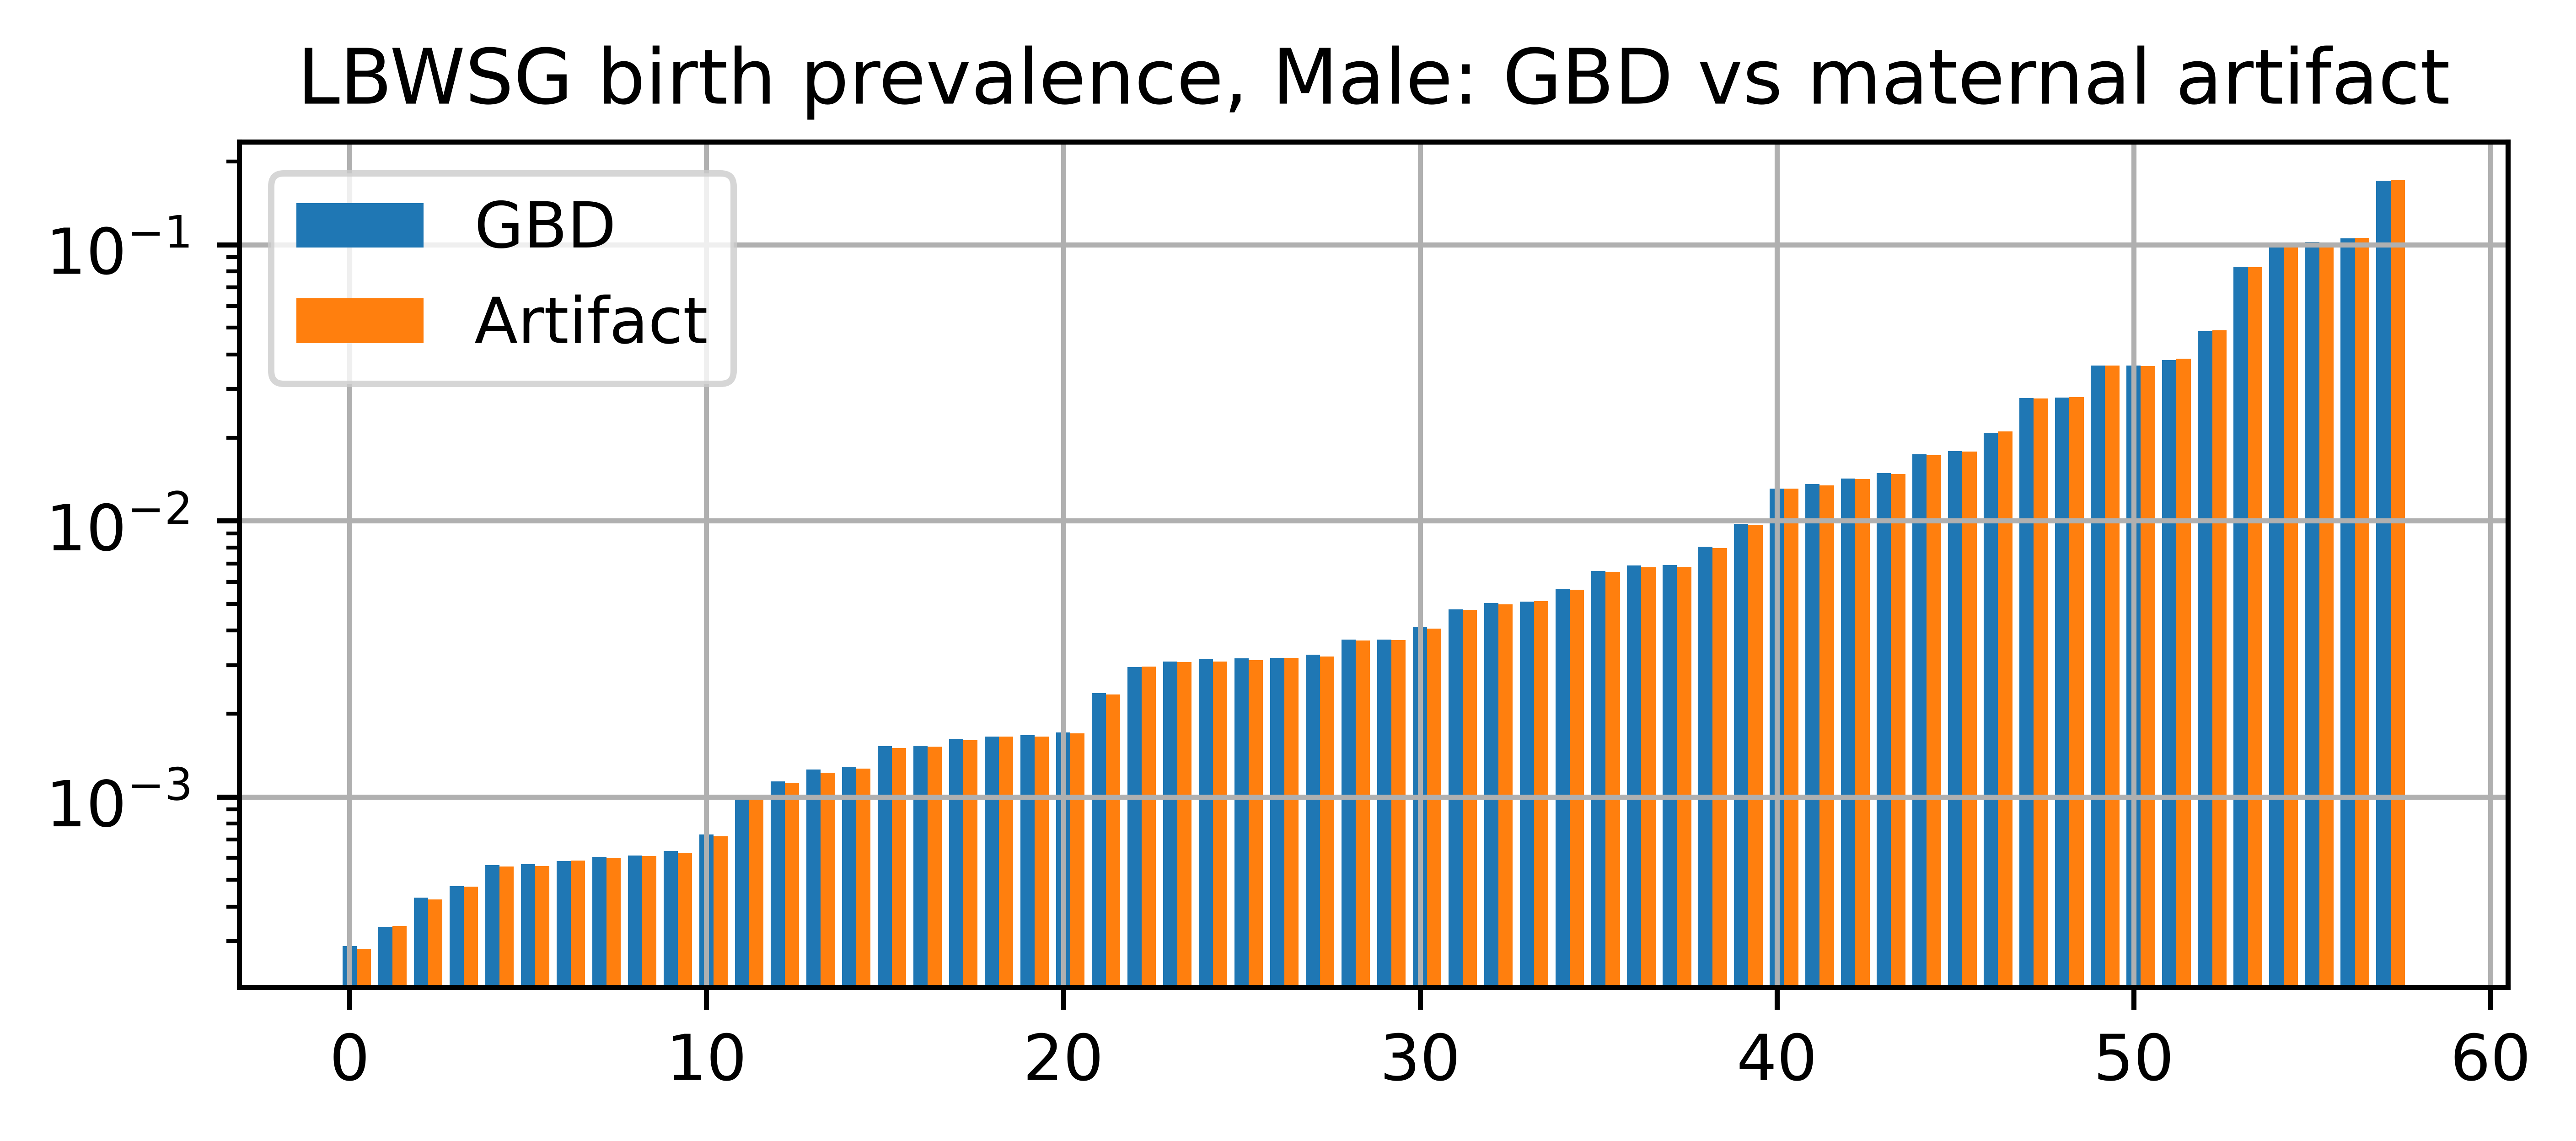

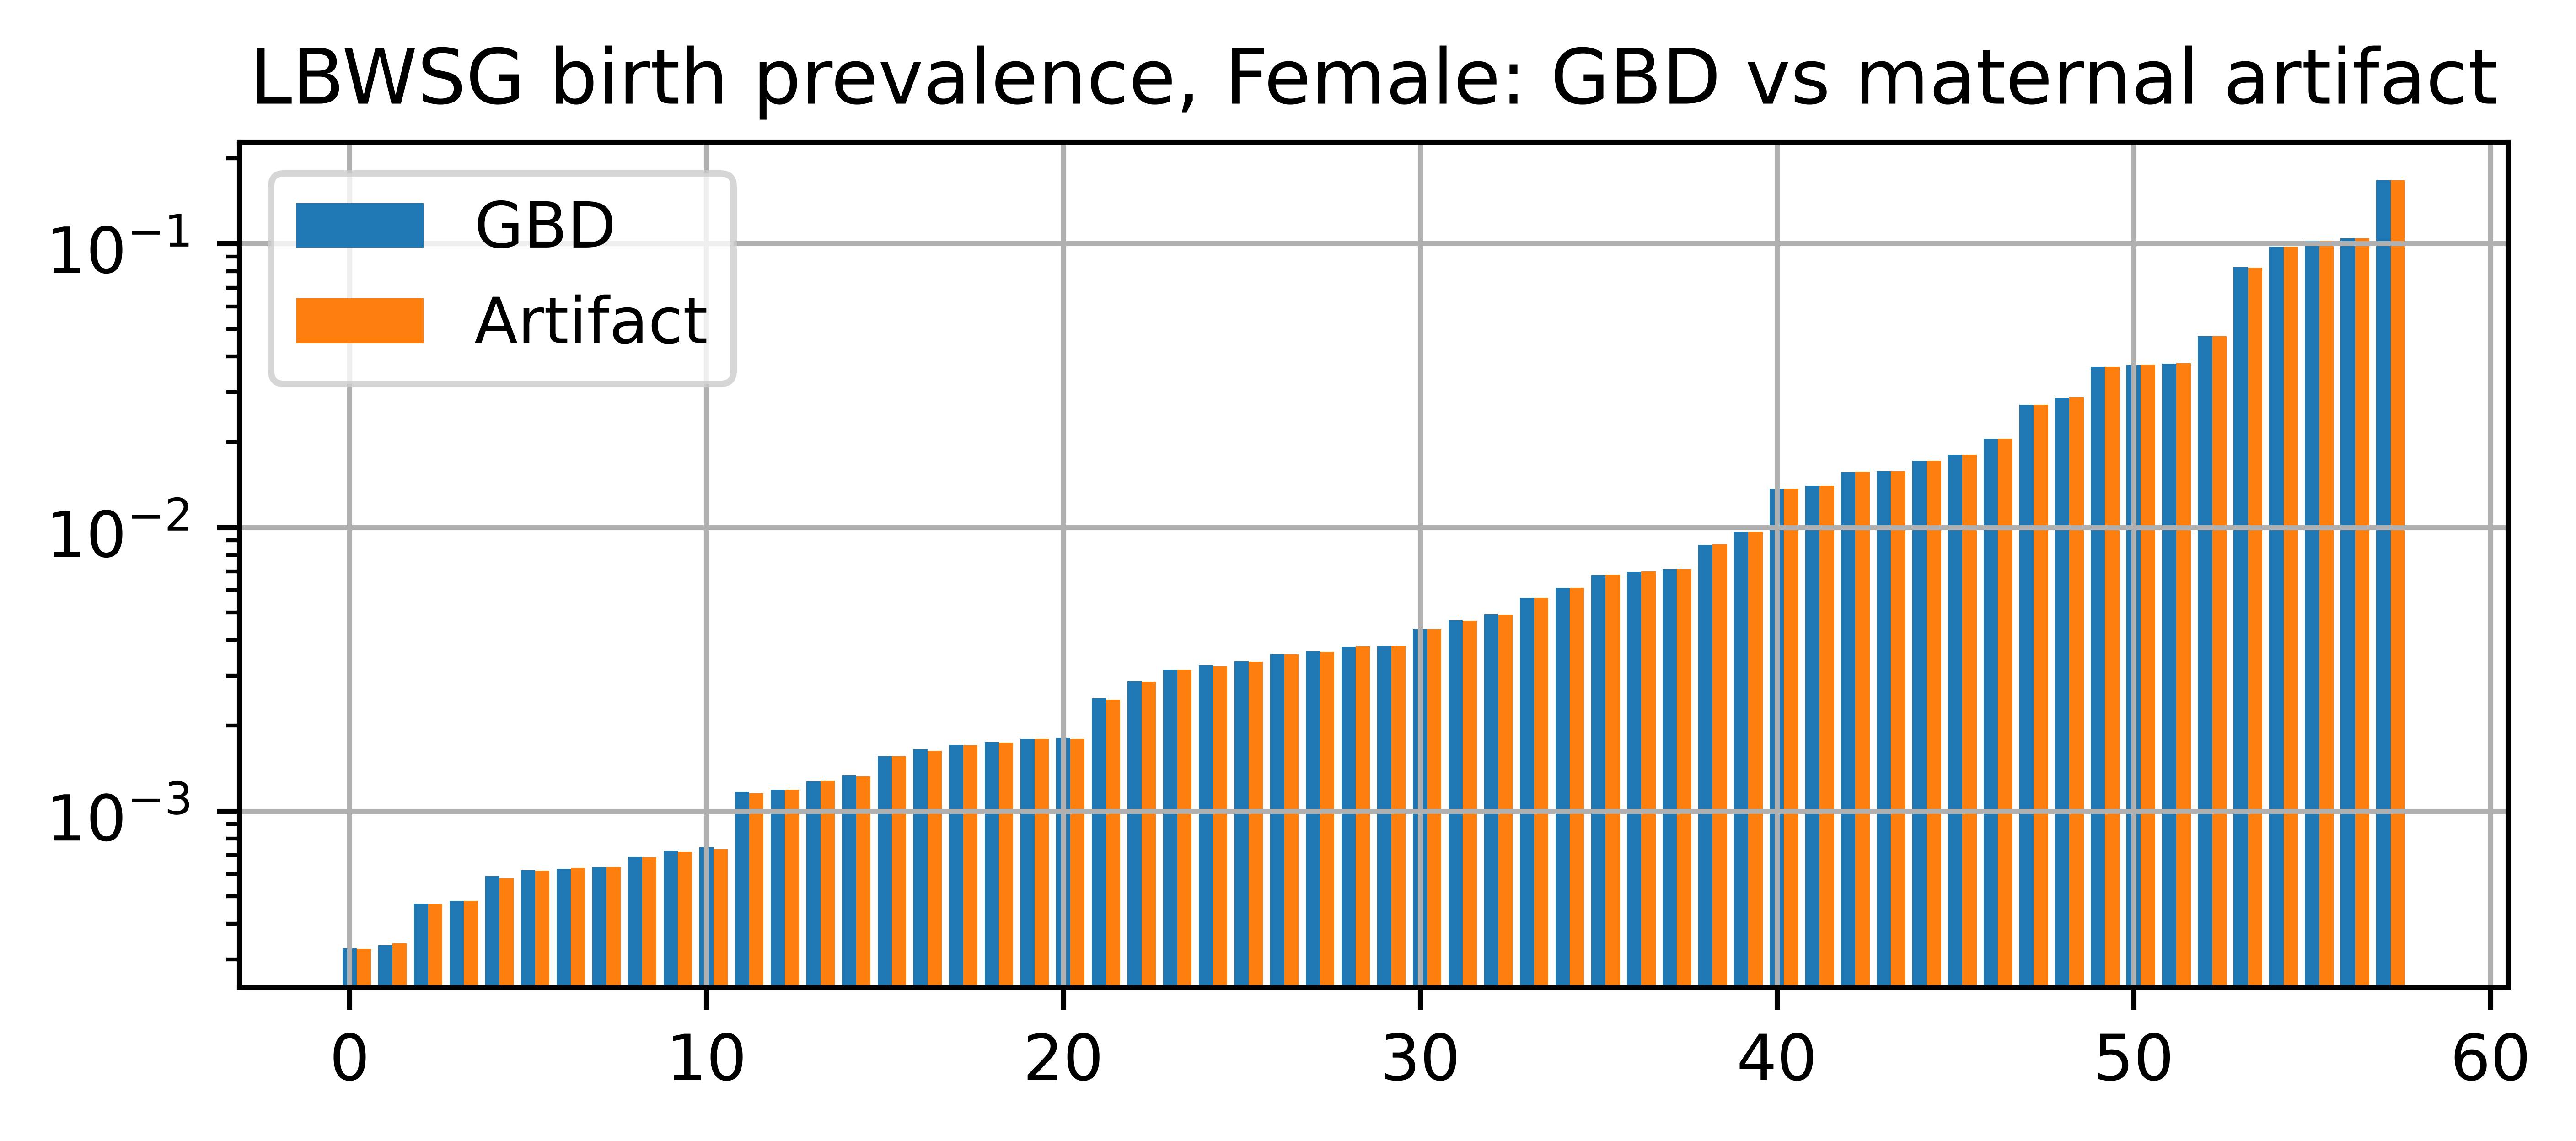

In [4]:
mat = (
    Artifact(maternal_artifact_dir)
    .load("risk_factor.low_birth_weight_and_short_gestation.exposure")
    .reset_index()
    .set_index(["sex", "parameter"])
    .draw_0.rename("artifact")
)
cmp = pd.concat([gbd_share(164), mat], axis=1)
worst = report(cmp, "birth prevalence")

width = 0.4
for sex in ["Male", "Female"]:
    p = cmp.xs(sex, level="sex").sort_values("gbd").reset_index()
    plt.figure(dpi=1000, figsize=(6.4, 2.4))
    plt.bar(p.index, p.gbd, width=width, label="GBD")
    plt.bar(p.index + width, p.artifact, width=width, label="Artifact")
    plt.grid()
    plt.legend()
    plt.semilogy()
    plt.title(f"LBWSG birth prevalence, {sex}: GBD vs maternal artifact")

Agreement is within a few percent, and only in the rarest categories -- consistent with a
best-model-version refresh between the artifact build and this pull (the RR comparison below
shows the pipeline itself is deterministic to machine precision).

## 2. Early/late-neonatal exposure: child artifact vs GBD (age groups 2 and 3)

The child artifact's rows carry year 2023 (vivarium_inputs carries the 2021 estimates forward),
so values should match the 2021 pull.

In [5]:
ce = Artifact(artifact_dir).load("risk_factor.low_birth_weight_and_short_gestation.exposure").reset_index()
for age_group_id, age_start, name in [(2, 0.0, "early neonatal"), (3, 0.019178, "late neonatal")]:
    ca = ce[np.isclose(ce.age_start, age_start)].set_index(["sex", "parameter"]).draw_0
    ca = (ca / ca.groupby("sex").transform("sum")).rename("artifact")
    cmp = pd.concat([gbd_share(age_group_id), ca], axis=1)
    worst = report(cmp, f"{name} exposure")
print("\nlargest relative differences (all in the rarest categories):")
print(worst.head(6).round(8).to_string())

early neonatal exposure: max |log(GBD/artifact)| = 0.248, exposure-weighted mean = 0.00325
late neonatal exposure: max |log(GBD/artifact)| = 0.266, exposure-weighted mean = 0.00308

largest relative differences (all in the rarest categories):
                       gbd  artifact
sex    parameter                    
Male   cat8       0.000022  0.000029
Female cat10      0.000093  0.000111
Male   cat2       0.000006  0.000007
Female cat8       0.000067  0.000075
Male   cat10      0.000043  0.000047
       cat11      0.000199  0.000211


Text(0.5, 1.0, 'LBWSG late-neonatal exposure, Female: GBD vs child artifact')

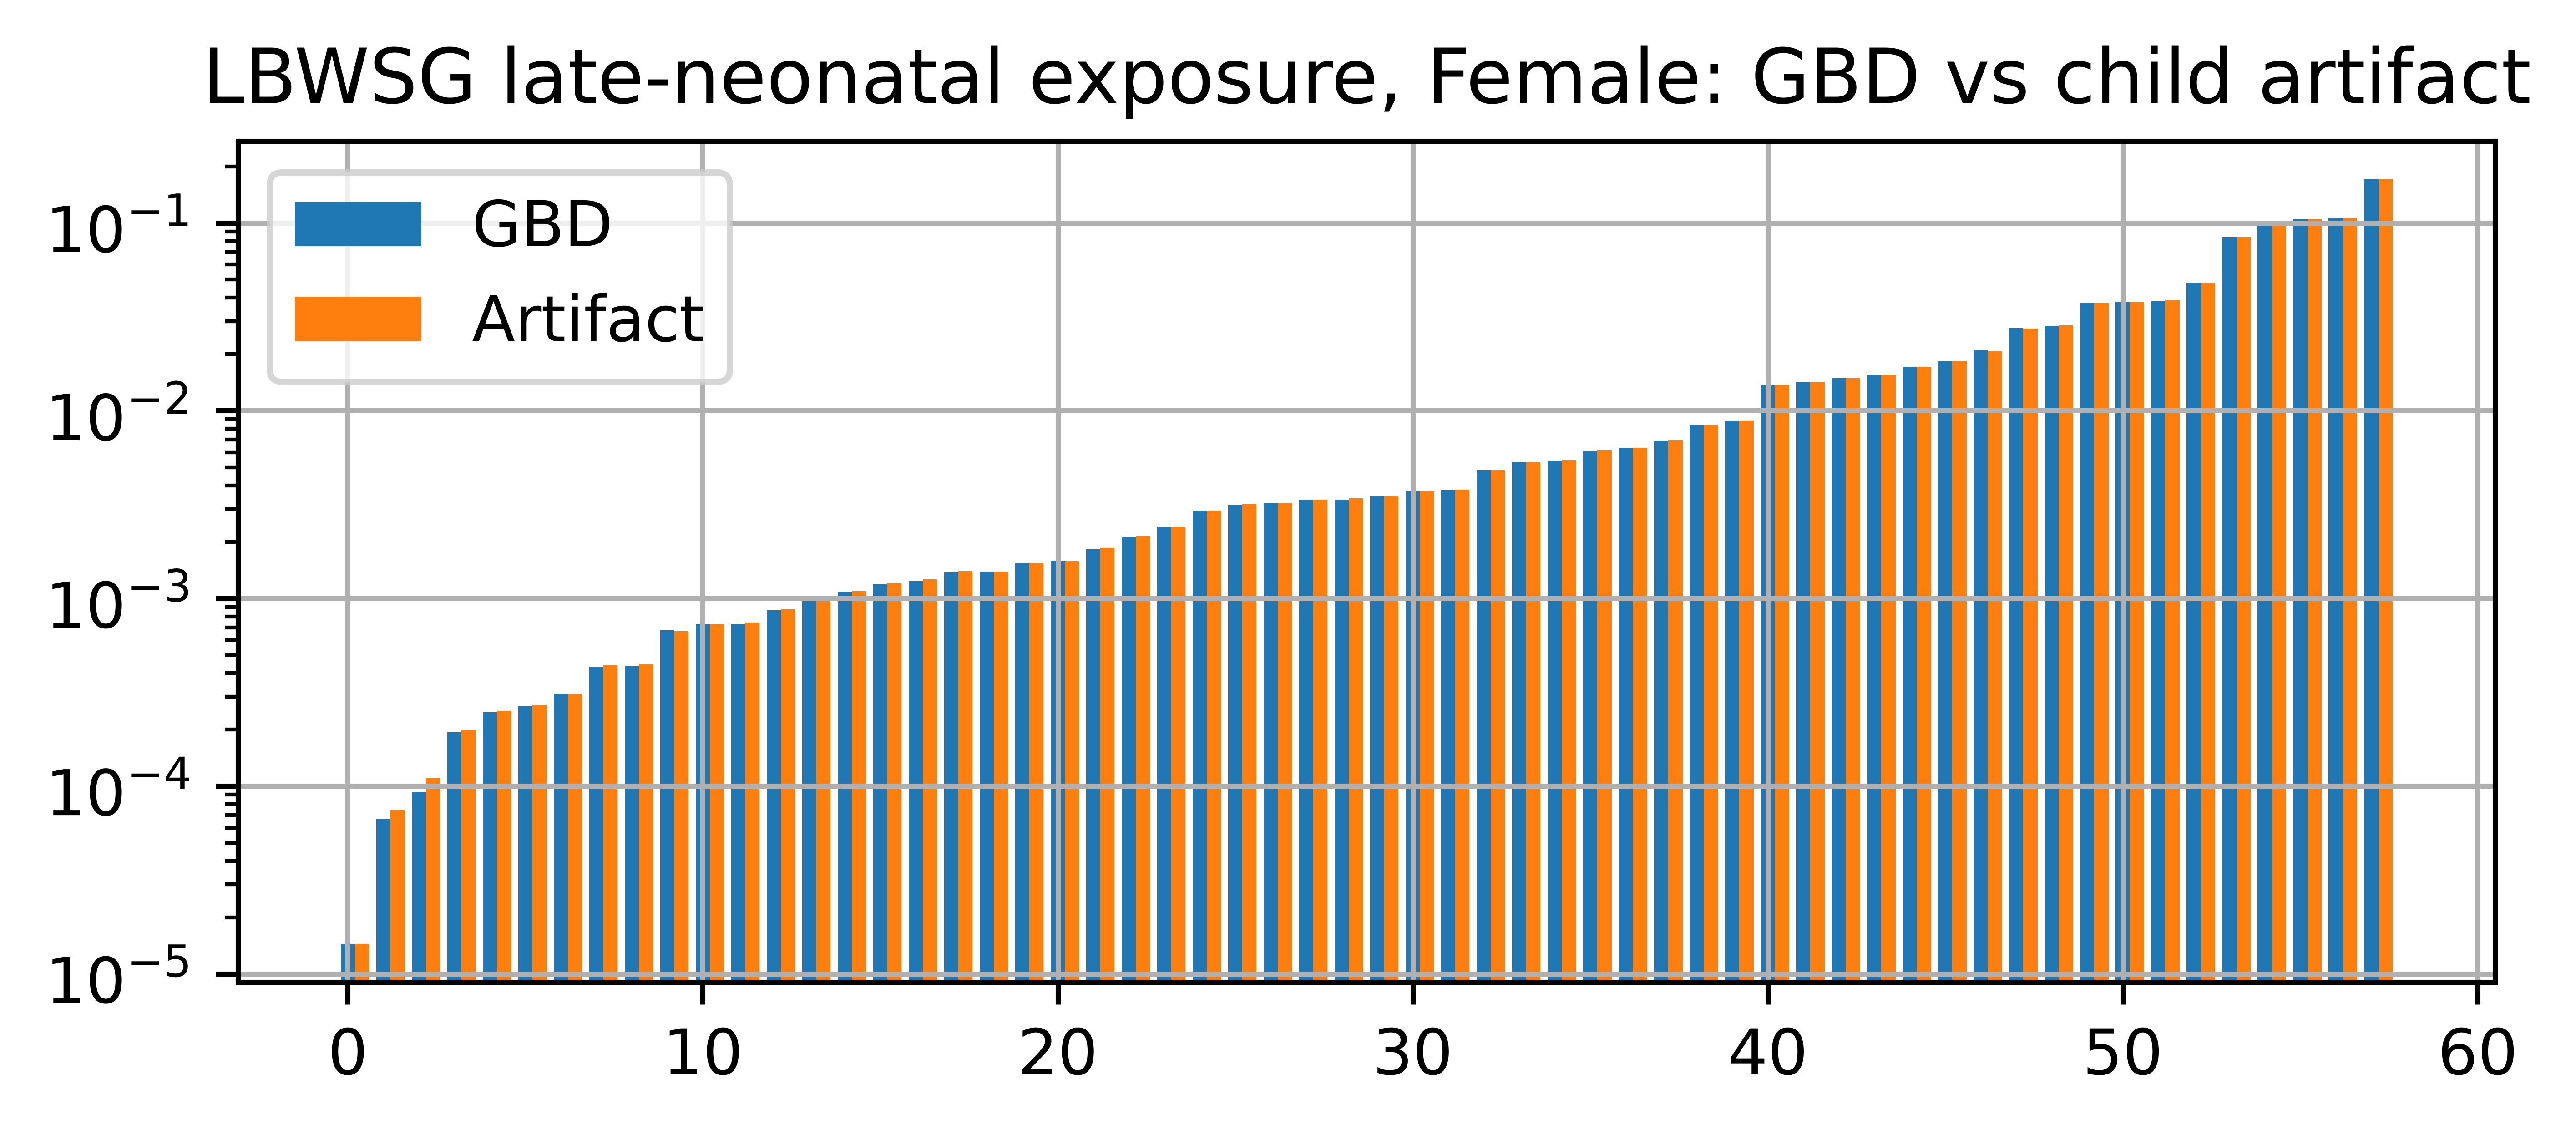

In [6]:
p = cmp.xs("Female", level="sex").sort_values("gbd").reset_index()
plt.figure(dpi=1000, figsize=(6.4, 2.4))
plt.bar(p.index, p.gbd, width=width, label="GBD")
plt.bar(p.index + width, p.artifact, width=width, label="Artifact")
plt.grid()
plt.legend()
plt.semilogy()
plt.title("LBWSG late-neonatal exposure, Female: GBD vs child artifact")

## 3. Raw category relative risks: child artifact vs GBD

This is the key ingredient check for the interpolator scramble: the artifact's *raw* RR key
should match GBD exactly, so the fix only needs to touch the interpolator build, not the data.

In [7]:
car = Artifact(artifact_dir).load("risk_factor.low_birth_weight_and_short_gestation.relative_risk").reset_index()
rr = rr_raw.copy()
rr["sex"] = rr.sex_id.map(SEX)
for age_group_id, age_start, name in [(2, 0.0, "early neonatal"), (3, 0.019178, "late neonatal")]:
    gbd_rr = (
        rr[rr.age_group_id == age_group_id]
        .set_index(["sex", "parameter"])[DRAW_COLS]
        .mean(axis=1)
        .rename("gbd")
    )
    art_rr = car[np.isclose(car.age_start, age_start)].set_index(["sex", "parameter"]).draw_0.rename("artifact")
    cmp = pd.concat([gbd_rr, art_rr], axis=1).dropna()
    max_err = np.log(cmp.gbd / cmp.artifact).abs().max()
    print(f"{name} RR ({len(cmp)} sex-category pairs): max |log(GBD/artifact)| = {max_err:.3g}")
    assert max_err < 1e-6, "raw RRs should match GBD exactly"
print("raw RRs match GBD exactly; the scramble is confined to the interpolator key")

early neonatal RR (116 sex-category pairs): max |log(GBD/artifact)| = 0
late neonatal RR (116 sex-category pairs): max |log(GBD/artifact)| = 0
raw RRs match GBD exactly; the scramble is confined to the interpolator key
